
### Baseline Fraud Detection Model - Logistic Regression

#### OBJECTIVE:
Build a baseline binary classification model to predict fraudulent Medicare claims.
This uses the pseudo-labels created in the previous notebook (fraud_label_creation).

#### APPROACH:
1. Load labeled data with features and fraud flags
2. Select relevant features for modeling
3. Split data into training and test sets
4. Handle class imbalance (fraud is rare ~4%)
5. Train Logistic Regression as interpretable baseline
6. Evaluate model performance
7. Analyze feature importance

#### WHY LOGISTIC REGRESSION?
- Interpretable: Coefficients show feature impact
- Fast to train: Good baseline to beat
- Probabilistic output: Can adjust decision threshold
- Industry standard: Shows understanding of fundamentals


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("BASELINE FRAUD DETECTION MODEL - LOGISTIC REGRESSION")
print("="*80)

BASELINE FRAUD DETECTION MODEL - LOGISTIC REGRESSION


In [2]:
print("\nPART 1: Loading labeled data...")
print("-" * 80)

# Load inpatient claims with fraud labels
# This dataset includes all features created in feature_engineering.ipynb
# and fraud labels from fraud_label_creation.ipynb
PROJECT_ROOT = Path().resolve().parents[1]
data_path = PROJECT_ROOT / "data" / "processed" 
inpatient = pd.read_csv(data_path / "inpatient_labeled.csv")

print(f"Dataset loaded: {inpatient.shape[0]:,} claims, {inpatient.shape[1]} columns")

# Check target variable distribution
fraud_rate = inpatient['is_fraud_80'].mean()
print(f"\nTarget variable: is_fraud_80")
print(f"  Fraud cases: {inpatient['is_fraud_80'].sum():,} ({fraud_rate*100:.2f}%)")
print(f"  Legitimate cases: {(inpatient['is_fraud_80']==0).sum():,} ({(1-fraud_rate)*100:.2f}%)")
print(f"  Class imbalance ratio: 1:{int((1-fraud_rate)/fraud_rate)}")


PART 1: Loading labeled data...
--------------------------------------------------------------------------------
Dataset loaded: 66,773 claims, 153 columns

Target variable: is_fraud_80
  Fraud cases: 229 (0.34%)
  Legitimate cases: 66,544 (99.66%)
  Class imbalance ratio: 1:290


In [3]:

# ==============================================================================
# PART 2: FEATURE SELECTION
# ==============================================================================

print("\nPART 2: Selecting features for modeling...")
print("-" * 80)

# Define feature groups
# We select features that are meaningful for fraud prediction
# and exclude ID columns, flags, and target variables

# Claim-level features: Payment amount, length of stay, code counts
claim_features = [
    'CLM_PMT_AMT',
    'length_of_stay',
    'payment_per_day',
    'diagnosis_code_count',
    'procedure_code_count',
    'hcpcs_code_count',
    'claim_day_of_week',
    'claim_is_weekend',
    'claim_month',
    'claim_quarter'
]

# Provider-level features: Captures provider behavior patterns
provider_features = [
    'provider_claim_count',
    'provider_avg_payment',
    'provider_median_payment',
    'provider_std_payment',
    'provider_payment_cv',
    'provider_unique_patients',
    'provider_claims_per_patient',
    'provider_volume_percentile',
    'provider_avg_payment_percentile'
]

# Beneficiary-level features: Captures patient utilization patterns
beneficiary_features = [
    'bene_claim_count',
    'bene_avg_payment',
    'bene_total_payment',
    'bene_std_payment',
    'bene_unique_providers',
    'bene_claim_span_days',
    'bene_claims_per_day',
    'bene_providers_per_claim',
    'bene_ip_claim_count',
    'bene_op_claim_count',
    'bene_ip_to_op_ratio'
]

# Demographic & clinical features
demographic_features = [
    'age',
    'gender',
    'chronic_condition_count',
    'has_multiple_conditions',
    'has_high_cost_condition'
]

# Statistical features: Derived metrics for outlier detection
statistical_features = [
    'payment_zscore',
    'payment_percentile',
    'payment_deviation_from_provider_avg',
    'payment_deviation_from_bene_avg',
    'cost_per_condition'
]

# Combine all feature groups
all_features = (claim_features + provider_features + 
                beneficiary_features + demographic_features + 
                statistical_features)

# Verify all features exist in dataset
available_features = [f for f in all_features if f in inpatient.columns]
missing_features = set(all_features) - set(available_features)

print(f"Total features selected: {len(available_features)}")
print(f"  Claim features: {len([f for f in claim_features if f in available_features])}")
print(f"  Provider features: {len([f for f in provider_features if f in available_features])}")
print(f"  Beneficiary features: {len([f for f in beneficiary_features if f in available_features])}")
print(f"  Demographic features: {len([f for f in demographic_features if f in available_features])}")
print(f"  Statistical features: {len([f for f in statistical_features if f in available_features])}")

if missing_features:
    print(f"\nWarning: {len(missing_features)} features not found in dataset")



PART 2: Selecting features for modeling...
--------------------------------------------------------------------------------
Total features selected: 40
  Claim features: 10
  Provider features: 9
  Beneficiary features: 11
  Demographic features: 5
  Statistical features: 5


In [4]:
# ==============================================================================
# PART 3: PREPARE DATA FOR MODELING
# ==============================================================================

print("\nPART 3: Preparing data for modeling...")
print("-" * 80)

# Extract features (X) and target (y)
X = inpatient[available_features].copy()
y = inpatient['is_fraud_80'].copy()

# Handle missing values
# Strategy: Fill with median (robust to outliers)
missing_counts = X.isnull().sum()
features_with_missing = missing_counts[missing_counts > 0]

if len(features_with_missing) > 0:
    print(f"\nHandling missing values in {len(features_with_missing)} features:")
    for feat in features_with_missing.index[:5]:  # Show first 5
        print(f"  {feat}: {missing_counts[feat]:,} missing ({missing_counts[feat]/len(X)*100:.1f}%)")
    
    # Fill missing values with median
    X = X.fillna(X.median())
    print("  Strategy: Filled with median values")
else:
    print("No missing values found")

# Check for infinite values
inf_counts = np.isinf(X).sum()
if inf_counts.sum() > 0:
    print(f"\nReplacing {inf_counts.sum()} infinite values with large finite numbers")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())

print(f"\nFinal dataset shape:")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")


PART 3: Preparing data for modeling...
--------------------------------------------------------------------------------

Handling missing values in 12 features:
  claim_day_of_week: 68 missing (0.1%)
  claim_month: 68 missing (0.1%)
  claim_quarter: 68 missing (0.1%)
  provider_std_payment: 59 missing (0.1%)
  provider_payment_cv: 59 missing (0.1%)
  Strategy: Filled with median values

Final dataset shape:
  Features (X): (66773, 40)
  Target (y): (66773,)


In [5]:

# ==============================================================================
# PART 4: TRAIN-TEST SPLIT
# ==============================================================================

print("\nPART 4: Splitting data into train and test sets...")
print("-" * 80)

# Split: 80% train, 20% test
# stratify=y ensures both sets have similar fraud rates
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} claims")
print(f"  Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")

print(f"\nTest set: {X_test.shape[0]:,} claims")
print(f"  Fraud: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")


PART 4: Splitting data into train and test sets...
--------------------------------------------------------------------------------
Training set: 53,418 claims
  Fraud: 183 (0.34%)
  Legitimate: 53,235 (99.66%)

Test set: 13,355 claims
  Fraud: 46 (0.34%)
  Legitimate: 13,309 (99.66%)


In [6]:
# ==============================================================================
# PART 5: FEATURE SCALING
# ==============================================================================

print("\nPART 5: Scaling features...")
print("-" * 80)

# Why scale? Logistic Regression is sensitive to feature magnitude
# Features like 'CLM_PMT_AMT' (0-100,000) vs 'age' (0-100) need normalization
# StandardScaler: (x - mean) / std_dev

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note: fit_transform on train, transform on test to avoid data leakage

print("Features standardized using StandardScaler")
print(f"  Mean: 0, Std: 1 for all features")


PART 5: Scaling features...
--------------------------------------------------------------------------------
Features standardized using StandardScaler
  Mean: 0, Std: 1 for all features


In [7]:

# ==============================================================================
# PART 6: HANDLE CLASS IMBALANCE WITH SMOTE
# ==============================================================================

print("\nPART 6: Handling class imbalance...")
print("-" * 80)

# Problem: Only ~4% fraud cases - model will bias toward majority class
# Solution: SMOTE (Synthetic Minority Over-sampling Technique)
# Creates synthetic fraud cases by interpolating between existing ones

print(f"Before SMOTE:")
print(f"  Training samples: {len(y_train):,}")
print(f"  Fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")

# Apply SMOTE
# sampling_strategy=0.5 means: fraud cases = 50% of legitimate cases
# This balances classes without making fraud the majority
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Training samples: {len(y_train_resampled):,}")
print(f"  Fraud: {y_train_resampled.sum():,} ({y_train_resampled.mean()*100:.2f}%)")
print(f"  Legitimate: {(y_train_resampled==0).sum():,}")

print("\nNote: SMOTE only applied to training set - test set remains unchanged")


PART 6: Handling class imbalance...
--------------------------------------------------------------------------------
Before SMOTE:
  Training samples: 53,418
  Fraud: 183 (0.34%)

After SMOTE:
  Training samples: 79,852
  Fraud: 26,617 (33.33%)
  Legitimate: 53,235

Note: SMOTE only applied to training set - test set remains unchanged


In [8]:

# ==============================================================================
# PART 7: TRAIN BASELINE MODEL
# ==============================================================================

print("\nPART 7: Training Logistic Regression model...")
print("-" * 80)

# Logistic Regression hyperparameters:
# - C=1.0: Regularization strength (lower = more regularization)
# - max_iter=1000: Iterations for convergence
# - class_weight='balanced': Automatically adjusts for class imbalance
# - random_state=42: Reproducibility

model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

# Train model on resampled data
model.fit(X_train_resampled, y_train_resampled)

print("Model training complete")
print(f"  Converged: {model.n_iter_[0] < model.max_iter}")
print(f"  Iterations: {model.n_iter_[0]}")


PART 7: Training Logistic Regression model...
--------------------------------------------------------------------------------
Model training complete
  Converged: True
  Iterations: 65


In [9]:

# ==============================================================================
# PART 8: MAKE PREDICTIONS
# ==============================================================================

print("\nPART 8: Making predictions on test set...")
print("-" * 80)

# Predict probabilities (probability of being fraud)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Predict classes using default threshold (0.5)
y_pred = model.predict(X_test_scaled)

print("Predictions generated")
print(f"  Probability range: [{y_pred_proba.min():.3f}, {y_pred_proba.max():.3f}]")
print(f"  Predicted fraud cases: {y_pred.sum():,} ({y_pred.mean()*100:.2f}%)")
print(f"  Actual fraud cases: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


PART 8: Making predictions on test set...
--------------------------------------------------------------------------------
Predictions generated
  Probability range: [0.000, 1.000]
  Predicted fraud cases: 132 (0.99%)
  Actual fraud cases: 46 (0.34%)


In [10]:

# ==============================================================================
# PART 9: EVALUATE MODEL PERFORMANCE
# ==============================================================================

print("\nPART 9: Evaluating model performance...")
print("-" * 80)

# Confusion Matrix
# Shows: True Positives, False Positives, True Negatives, False Negatives
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print("                  Predicted")
print("                Legit   Fraud")
print(f"Actual Legit    {cm[0,0]:6,}  {cm[0,1]:6,}")
print(f"       Fraud    {cm[1,0]:6,}  {cm[1,1]:6,}")

# Calculate key metrics
tn, fp, fn, tp = cm.ravel()

print("\nMetric Breakdown:")
print(f"  True Negatives (TN):  {tn:6,} - Correctly identified legitimate claims")
print(f"  False Positives (FP): {fp:6,} - Legitimate claims flagged as fraud")
print(f"  False Negatives (FN): {fn:6,} - Fraud cases missed")
print(f"  True Positives (TP):  {tp:6,} - Correctly identified fraud")

# Classification Report
# Precision: Of flagged cases, what % are actually fraud?
# Recall: Of actual fraud, what % did we catch?
# F1-Score: Harmonic mean of precision and recall
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# ROC-AUC Score
# Measures model's ability to distinguish between classes
# 1.0 = perfect, 0.5 = random guessing
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")
print("  Interpretation: Model's ability to rank fraud higher than legitimate")
print(f"  {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'} performance")



PART 9: Evaluating model performance...
--------------------------------------------------------------------------------

Confusion Matrix:
                  Predicted
                Legit   Fraud
Actual Legit    13,221      88
       Fraud         2      44

Metric Breakdown:
  True Negatives (TN):  13,221 - Correctly identified legitimate claims
  False Positives (FP):     88 - Legitimate claims flagged as fraud
  False Negatives (FN):      2 - Fraud cases missed
  True Positives (TP):      44 - Correctly identified fraud

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     13309
       Fraud       0.33      0.96      0.49        46

    accuracy                           0.99     13355
   macro avg       0.67      0.97      0.75     13355
weighted avg       1.00      0.99      0.99     13355


ROC-AUC Score: 0.9981
  Interpretation: Model's ability to rank fraud higher than legitimate
  Excellent performance


PART 10: Visualizing model performance...
--------------------------------------------------------------------------------


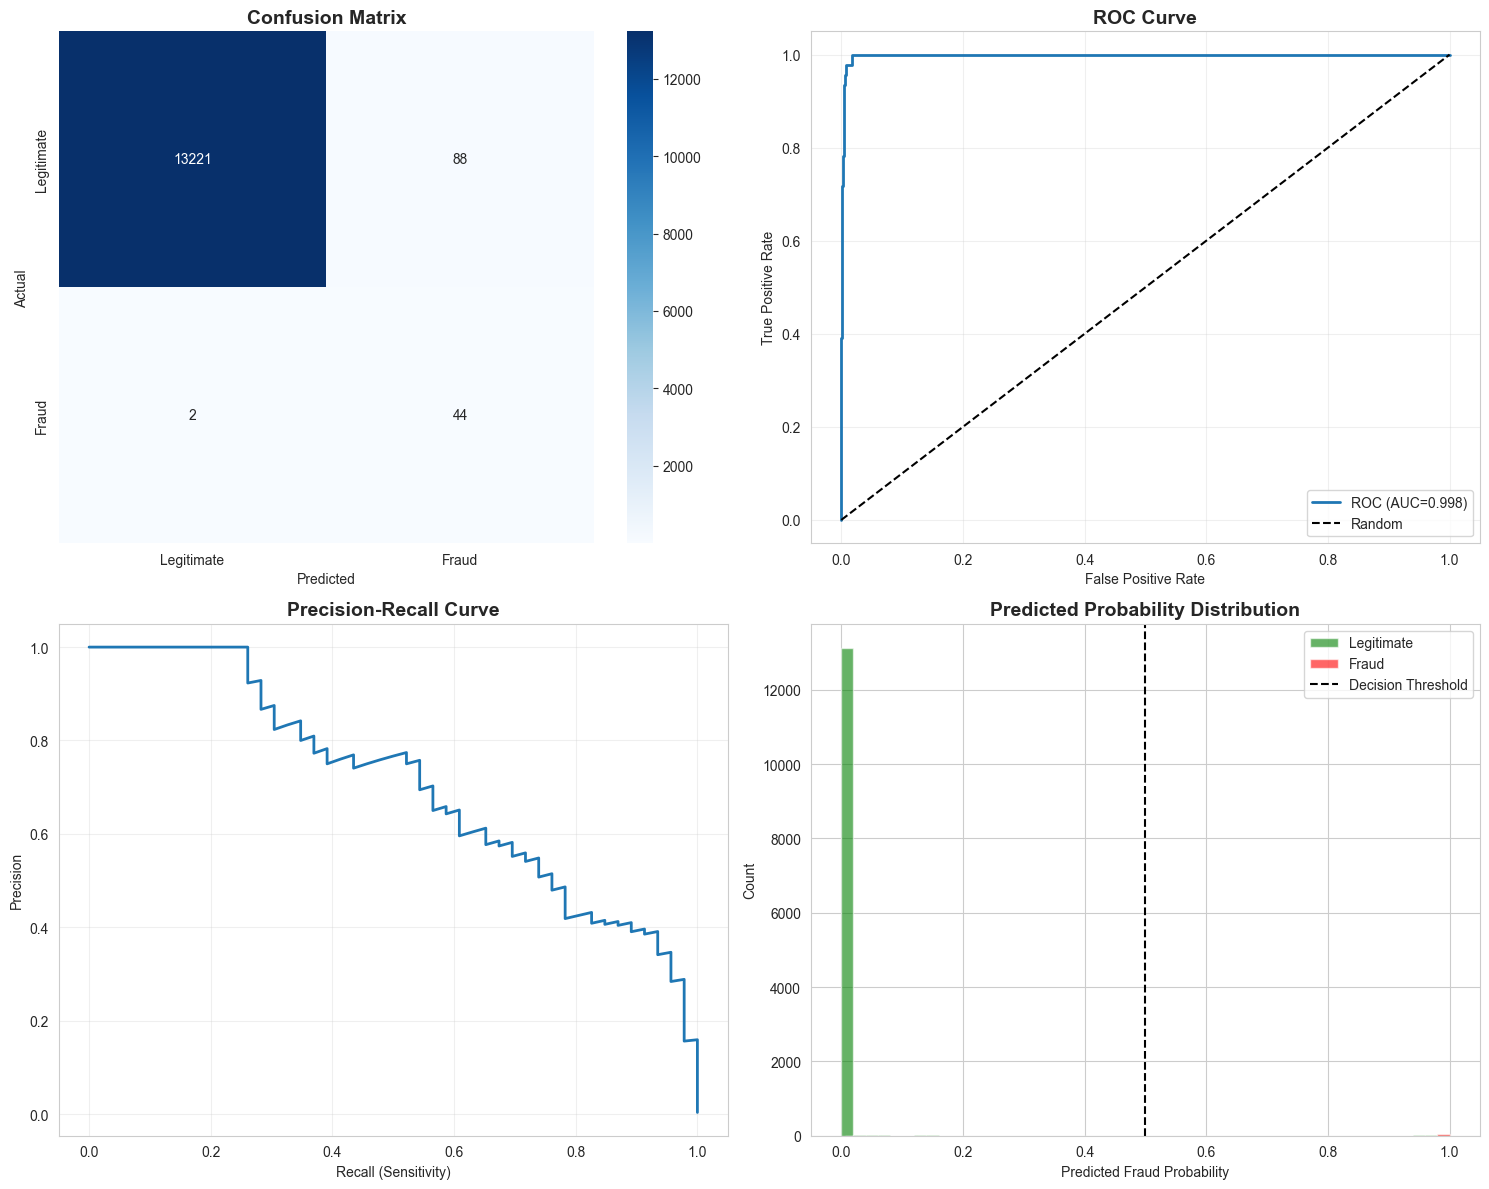

Visualizations saved to: ../docs/baseline_model_performance.png


In [12]:

# ==============================================================================
# PART 10: VISUALIZE RESULTS
# ==============================================================================

print("\nPART 10: Visualizing model performance...")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], 
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0,0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# Plot 2: ROC Curve
# Shows trade-off between True Positive Rate and False Positive Rate
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
axes[0,1].plot(fpr, tpr, linewidth=2, label=f'ROC (AUC={roc_auc:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# Plot 3: Precision-Recall Curve
# More informative for imbalanced datasets than ROC
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
axes[1,0].plot(recall, precision, linewidth=2)
axes[1,0].set_xlabel('Recall (Sensitivity)')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1,0].grid(alpha=0.3)

# Plot 4: Predicted Probability Distribution
# Shows separation between fraud and legitimate claims
axes[1,1].hist(y_pred_proba[y_test==0], bins=50, alpha=0.6, label='Legitimate', color='green')
axes[1,1].hist(y_pred_proba[y_test==1], bins=50, alpha=0.6, label='Fraud', color='red')
axes[1,1].axvline(0.5, color='black', linestyle='--', label='Decision Threshold')
axes[1,1].set_xlabel('Predicted Fraud Probability')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Predicted Probability Distribution', fontsize=14, fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'baseline_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved to: ../docs/baseline_model_performance.png")



PART 11: Analyzing feature importance...
--------------------------------------------------------------------------------

Top 15 Most Important Features:
--------------------------------------------------------------------------------
  payment_percentile                        -4.971 (decreases fraud risk)
  provider_payment_cv                        3.110 (increases fraud risk)
  procedure_code_count                       2.969 (increases fraud risk)
  provider_volume_percentile                 2.720 (increases fraud risk)
  provider_avg_payment                       2.488 (increases fraud risk)
  claim_is_weekend                           2.270 (increases fraud risk)
  bene_unique_providers                      1.441 (increases fraud risk)
  provider_avg_payment_percentile           -1.419 (decreases fraud risk)
  CLM_PMT_AMT                                1.338 (increases fraud risk)
  payment_zscore                             1.338 (increases fraud risk)
  payment_deviation_fro

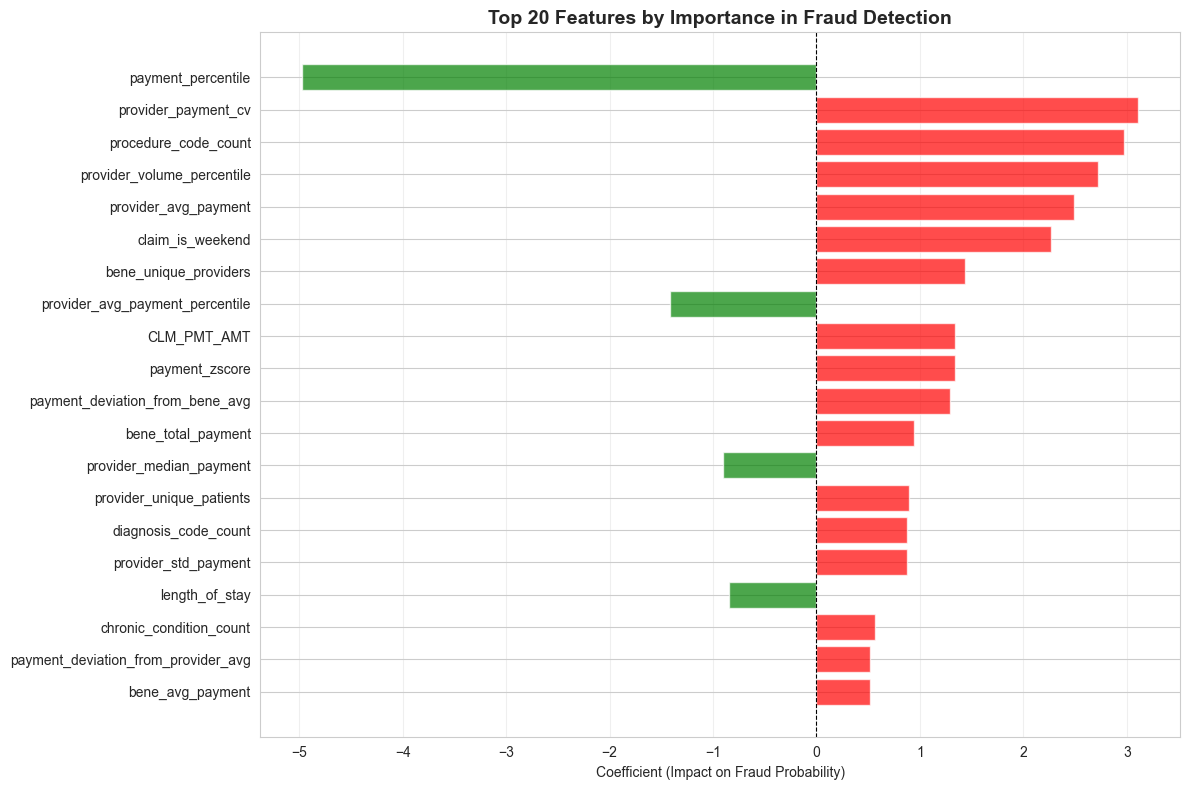


Feature importance chart saved to: ../docs/feature_importance.png


In [14]:

# ==============================================================================
# PART 11: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================

print("\nPART 11: Analyzing feature importance...")
print("-" * 80)

# Logistic Regression coefficients show feature impact
# Positive coefficient: Feature increases fraud probability
# Negative coefficient: Feature decreases fraud probability
# Magnitude: Strength of effect

feature_importance = pd.DataFrame({
    'feature': available_features,
    'coefficient': model.coef_[0]
})

# Sort by absolute value to find most impactful features
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print("\nTop 15 Most Important Features:")
print("-" * 80)
for idx, row in feature_importance.head(15).iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"  {row['feature']:40} {row['coefficient']:7.3f} ({direction} fraud risk)")

# Visualize top features
plt.figure(figsize=(12, 8))
top_n = 20
top_features = feature_importance.head(top_n)

colors = ['red' if c > 0 else 'green' for c in top_features['coefficient']]
plt.barh(range(len(top_features)), top_features['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coefficient (Impact on Fraud Probability)')
plt.title(f'Top {top_n} Features by Importance in Fraud Detection', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT/'docs'/'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature importance chart saved to: ../docs/feature_importance.png")


In [15]:

# ==============================================================================
# PART 12: SAVE MODEL AND RESULTS
# ==============================================================================

print("\nPART 12: Saving model and results...")
print("-" * 80)

import joblib

# Save trained model
model_path = PROJECT_ROOT/'models'/'fraud'/'baseline_logistic_regression.pkl'
joblib.dump(model, model_path)
print(f"Model saved: {model_path}")

# Save scaler (needed for production predictions)
scaler_path = PROJECT_ROOT/'models'/'fraud'/'feature_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler saved: {scaler_path}")

# Save feature list (needed for production)
feature_path = PROJECT_ROOT/'models'/'fraud'/'feature_list.pkl'
joblib.dump(available_features, feature_path)
print(f"Feature list saved: {feature_path}")

# Save performance metrics
results = {
    'model': 'Logistic Regression',
    'roc_auc': roc_auc,
    'precision': precision[np.argmax(precision >= 0.7)] if any(precision >= 0.7) else precision.max(),
    'recall': recall[np.argmax(precision >= 0.7)] if any(precision >= 0.7) else recall[np.argmax(precision)],
    'f1_score': f1_score(y_test, y_pred),
    'test_size': len(y_test),
    'fraud_rate': y_test.mean(),
    'top_features': feature_importance.head(10)['feature'].tolist()
}

results_df = pd.DataFrame([results])
results_df.to_csv(PROJECT_ROOT/'models'/'fraud'/'baseline_results.csv', index=False)
print(f"Results saved: ../models/fraud/baseline_results.csv")



PART 12: Saving model and results...
--------------------------------------------------------------------------------
Model saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\baseline_logistic_regression.pkl
Scaler saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\feature_scaler.pkl
Feature list saved: C:\Users\amrit\PythonPractice\Machine learning\healthcare-analytics-platform\models\fraud\feature_list.pkl
Results saved: ../models/fraud/baseline_results.csv


In [16]:

# ==============================================================================
# SUMMARY
# ==============================================================================

print("\n" + "="*80)
print("BASELINE MODEL TRAINING COMPLETE")
print("="*80)

print(f"""
MODEL SUMMARY:
  Algorithm: Logistic Regression
  Training samples: {len(y_train_resampled):,} (after SMOTE)
  Test samples: {len(y_test):,}
  Features: {len(available_features)}

PERFORMANCE METRICS:
  ROC-AUC: {roc_auc:.4f}
  Precision: {precision[np.argmax(precision >= 0.7)] if any(precision >= 0.7) else precision.max():.4f}
  Recall: {recall[np.argmax(precision >= 0.7)] if any(precision >= 0.7) else recall[np.argmax(precision)]:.4f}
  F1-Score: {f1_score(y_test, y_pred):.4f}

BUSINESS IMPACT (if deployed):
  True Positives: {tp:,} fraud cases detected
  False Positives: {fp:,} legitimate claims flagged (for manual review)
  False Negatives: {fn:,} fraud cases missed
  True Negatives: {tn:,} legitimate claims correctly cleared

TOP 3 FRAUD INDICATORS:
  1. {feature_importance.iloc[0]['feature']}
  2. {feature_importance.iloc[1]['feature']}
  3. {feature_importance.iloc[2]['feature']}

NEXT STEPS:
  1. Train advanced models (XGBoost, Random Forest)
  2. Optimize decision threshold for business needs
  3. Implement model explainability (SHAP values)
  4. Deploy model as API endpoint
""")

print("="*80)


BASELINE MODEL TRAINING COMPLETE

MODEL SUMMARY:
  Algorithm: Logistic Regression
  Training samples: 79,852 (after SMOTE)
  Test samples: 13,355
  Features: 40

PERFORMANCE METRICS:
  ROC-AUC: 0.9981
  Precision: 0.7027
  Recall: 0.5652
  F1-Score: 0.4944

BUSINESS IMPACT (if deployed):
  True Positives: 44 fraud cases detected
  False Positives: 88 legitimate claims flagged (for manual review)
  False Negatives: 2 fraud cases missed
  True Negatives: 13,221 legitimate claims correctly cleared

TOP 3 FRAUD INDICATORS:
  1. payment_percentile
  2. provider_payment_cv
  3. procedure_code_count

NEXT STEPS:
  1. Train advanced models (XGBoost, Random Forest)
  2. Optimize decision threshold for business needs
  3. Implement model explainability (SHAP values)
  4. Deploy model as API endpoint

